In [5]:
from nnscaling import aesthetics
from nnscaling.data import (
    DatasetConfig,
    get_dataset_class,
)
from nnscaling.models import MLP, ScaledModel
from nnscaling.utils import compute_model_accuracy
from nnscaling.visualization import plot_decision_boundary

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
# Dataset config
dataset_config = DatasetConfig(
    dataset_name="YinYangNoDotsBinaryDataset",
    num_samples=3_000,
    split="train",
    seed=42,
)
DatasetClass = get_dataset_class(name=dataset_config.dataset_name)
dataset = DatasetClass(config=dataset_config)

In [7]:
file_path = "/home/nsa325/work/nnscaling/model_saves/yinyang_model.safetensors"
model = MLP.load_model(file_path).eval()

Testing Accuracy: 0.9926666617393494


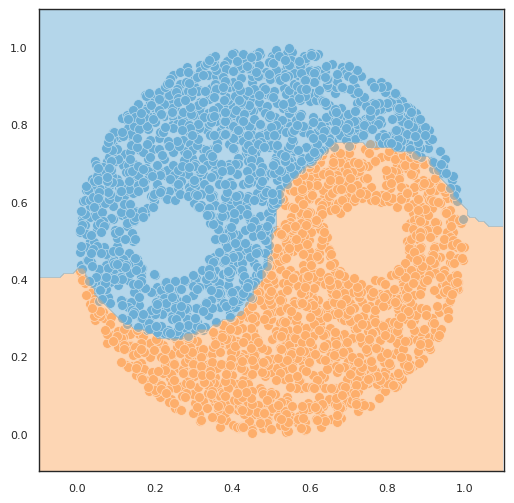

In [8]:
print(f"Testing Accuracy: {compute_model_accuracy(model.to('cpu'), dataset)}")

plot_decision_boundary(
    model,
    model.state_dict(),
    dataset.features,
    dataset.labels.squeeze(),
    labels=[0, 1],
)

In [9]:
file_path = "/home/nsa325/work/nnscaling/model_saves/scaling/loc_2_scaled_yinyang_model.safetensors"
scaled_model = ScaledModel.load_model(model, file_path).eval()

/home/nsa325/work/nnscaling/nnscaling/models/scaler.py:73: UserWarning: The `forward` method calls the `forward_scaled` method. For vanilla forward, call `forward_raw`.
  warnings.warn(
/home/nsa325/work/nnscaling/nnscaling/models/scaler.py:73: UserWarning: The `forward` method calls the `forward_scaled` method. For vanilla forward, call `forward_raw`.
  warnings.warn(


Testing Accuracy: 0.9783333539962769


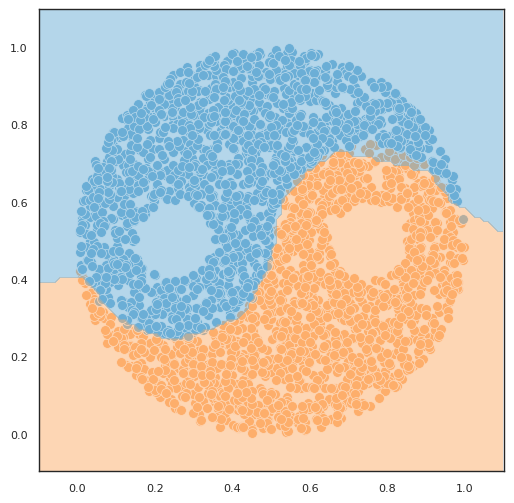

In [10]:
print(f"Testing Accuracy: {compute_model_accuracy(scaled_model.to('cpu'), dataset)}")

plot_decision_boundary(
    scaled_model,
    scaled_model.state_dict(),
    dataset.features,
    dataset.labels.squeeze(),
    labels=[0, 1],
)